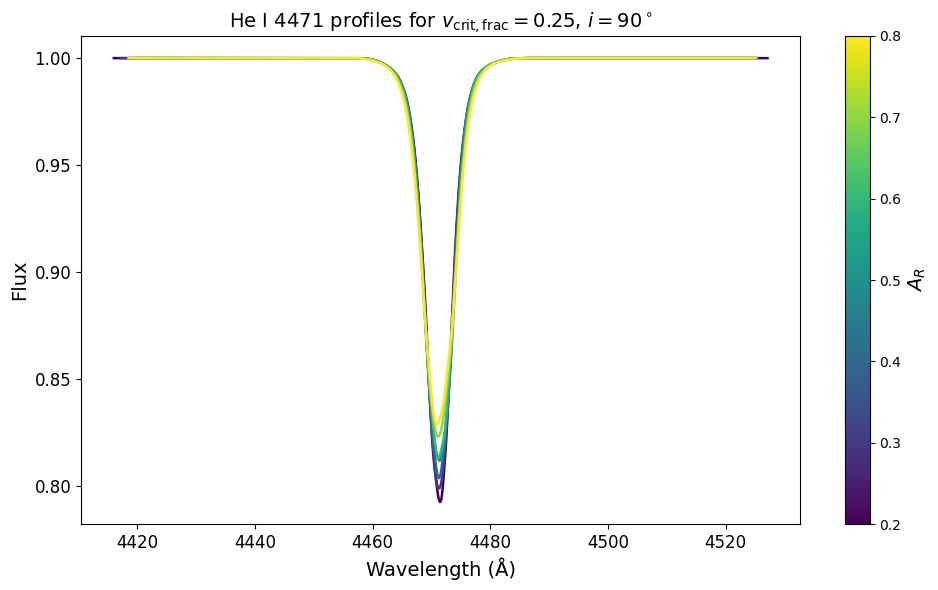

In [3]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

base_dir = "/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/inclination_vcrit_AR_grid"

def read_model_info(filepath):
    params = {}
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line or ":" not in line:
                continue
            key, val = line.split(":", 1)
            params[key.strip()] = val.strip()
    return params

def safe_float(val):
    try:
        return float(val)
    except Exception:
        return None

model_dirs = sorted(glob.glob(os.path.join(base_dir, "Model_*")))

selected_profiles = []

for model_dir in model_dirs:
    info_file = os.path.join(model_dir, "model_info.txt")
    if not os.path.isfile(info_file):
        continue

    params = read_model_info(info_file)

    vcrit = safe_float(params.get("v_crit_frac"))
    incl = safe_float(params.get("inclination"))
    A_R = safe_float(params.get("A_R"))

    if vcrit != 0.25 or incl != 90.0:
        continue

    # find the abundance/grid subfolder
    subdirs = [d for d in glob.glob(os.path.join(model_dir, "*")) if os.path.isdir(d)]
    if not subdirs:
        continue

    # assume only one such folder exists
    prof_dir = subdirs[0]

    line_file = os.path.join(prof_dir, "hjd0.00000000000_HEI4471.txt")
    if not os.path.isfile(line_file):
        continue

    data = np.loadtxt(line_file)
    wave = data[:, 0]
    flux = data[:, 1]

    selected_profiles.append((A_R, wave, flux, os.path.basename(model_dir)))

if not selected_profiles:
    print("No matching models found.")
else:
    # sort by A_R
    selected_profiles.sort(key=lambda x: x[0])

    A_R_vals = [x[0] for x in selected_profiles]
    norm = Normalize(vmin=min(A_R_vals), vmax=max(A_R_vals))
    cmap = cm.viridis

    fig, ax = plt.subplots(figsize=(10, 6))

    for A_R, wave, flux, model_name in selected_profiles:
        ax.plot(
            wave,
            flux,
            color=cmap(norm(A_R)),
            lw=1.8
        )

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"$A_R$", fontsize=14)

    ax.set_xlabel("Wavelength (Å)", fontsize=14)
    ax.set_ylabel("Flux", fontsize=14)
    ax.set_title(r"He I 4471 profiles for $v_{\rm crit,frac}=0.25$, $i=90^\circ$", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    #ax.invert_yaxis()   # optional for absorption lines

    plt.tight_layout()
    plt.show()

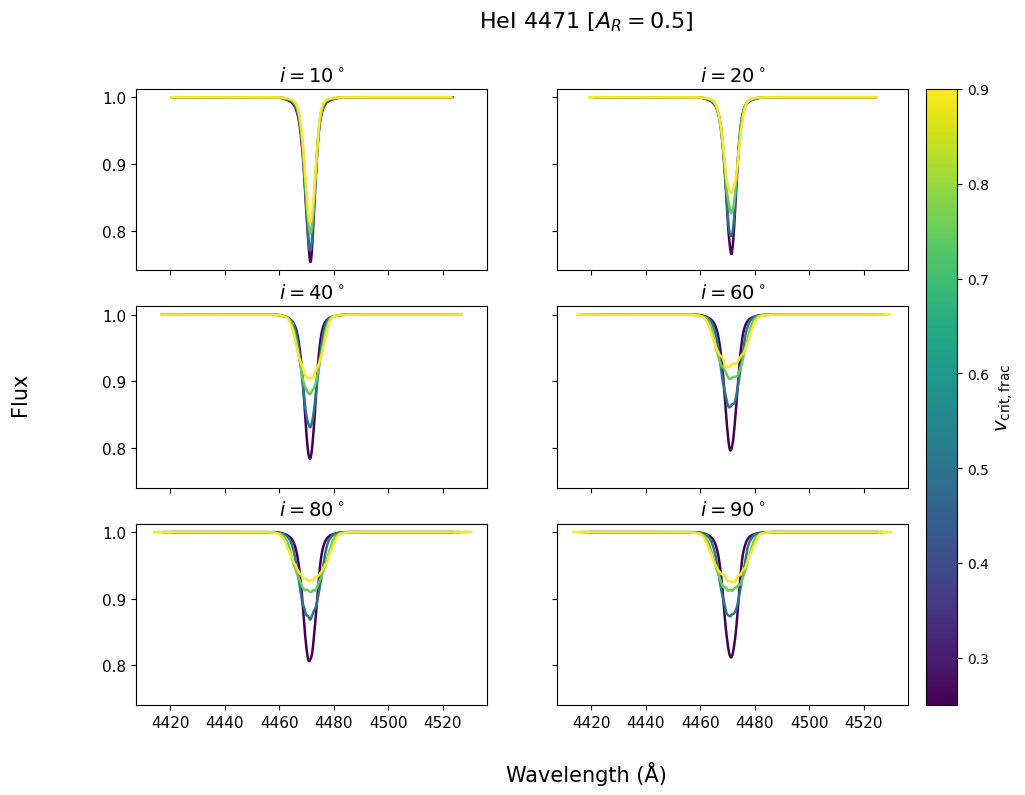

In [4]:
base_dir = "/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/inclination_vcrit_AR_grid"

def read_model_info(filepath):
    params = {}
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line or ":" not in line:
                continue
            key, val = line.split(":", 1)
            params[key.strip()] = val.strip()
    return params

def safe_float(val):
    try:
        return float(val)
    except Exception:
        return None

model_dirs = sorted(glob.glob(os.path.join(base_dir, "Model_*")))

selected_profiles = []

for model_dir in model_dirs:
    info_file = os.path.join(model_dir, "model_info.txt")
    if not os.path.isfile(info_file):
        continue

    params = read_model_info(info_file)

    A_R = safe_float(params.get("A_R"))
    incl = safe_float(params.get("inclination"))
    vcrit = safe_float(params.get("v_crit_frac"))

    if A_R is None or incl is None or vcrit is None:
        continue

    if not np.isclose(A_R, 0.5, atol=1e-6):
        continue

    subdirs = [d for d in glob.glob(os.path.join(model_dir, "*")) if os.path.isdir(d)]
    if not subdirs:
        continue

    prof_dir = subdirs[0]
    line_file = os.path.join(prof_dir, "hjd0.00000000000_HEI4471.txt")

    if not os.path.isfile(line_file):
        continue

    data = np.loadtxt(line_file)
    wave = data[:, 0]
    flux = data[:, 1]

    selected_profiles.append({
        "inclination": incl,
        "vcrit": vcrit,
        "wave": wave,
        "flux": flux,
        "model": os.path.basename(model_dir)
    })

if len(selected_profiles) == 0:
    print("No matching models found for A_R = 0.5")
else:
    inclinations = sorted(set(d["inclination"] for d in selected_profiles))
    vcrit_vals = [d["vcrit"] for d in selected_profiles]

    norm = Normalize(vmin=min(vcrit_vals), vmax=max(vcrit_vals))
    cmap = cm.viridis

    fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, incl in zip(axes, inclinations):
        subset = [d for d in selected_profiles if np.isclose(d["inclination"], incl, atol=1e-6)]

        subset = sorted(subset, key=lambda x: x["vcrit"])

        for d in subset:
            ax.plot(
                d["wave"],
                d["flux"],
                color=cmap(norm(d["vcrit"])),
                lw=1.8
            )

        ax.set_title(rf"$i = {incl:.0f}^\circ$", fontsize=14)
        ax.tick_params(axis='both', labelsize=11)
        ax.invert_yaxis()

    # hide unused panels if fewer than 6 inclinations
    for j in range(len(inclinations), len(axes)):
        axes[j].axis("off")

    fig.supxlabel("Wavelength (Å)", fontsize=15)
    fig.supylabel("Flux", fontsize=15)
    fig.suptitle(r"HeI 4471 [$A_R = 0.5$]", fontsize=16)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), pad=0.02)
    cbar.set_label(r"$v_{\rm crit,frac}$", fontsize=14)

    #plt.tight_layout(rect=[0, 0, 0.92, 0.96])
    plt.show()

#### non radial velocity field

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import phoebe, sys
from scipy.special import sph_harm
from astropy.constants import R_sun, M_sun, G
from phoebe import u
sys.path.append('/home/c4011027/PhD_stuff/SPAMMS')
import spamms as sp


In [2]:
input_file = '/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt'

fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
times, obs_specs = sp.get_obs_spec_and_times(io_dict)

run_dictionaries = sp.create_runs_and_ids(fit_param_values)

run_dictionary = run_dictionaries[0]  # choose model index here

s = sp.run_sb_phoebe_model(
    times,
    abund_param_values,
    io_dict,
    run_dictionary
)

Reading input file...


100%|██████████| 2/2 [00:03<00:00,  1.88s/it]


In [3]:


hjd = times[0]
s_t = s['%09.6f' % hjd]

x = s_t['us@primary'].get_value()
y = s_t['vs@primary'].get_value()
z = s_t['ws@primary'].get_value()

vx = s_t['vus@primary'].get_value(unit=u.km/u.s)
vy = s_t['vvs@primary'].get_value(unit=u.km/u.s)
vz = s_t['vws@primary'].get_value(unit=u.km/u.s)

rvs = s_t['rvs@primary@mesh'].get_value(unit=u.km/u.s)
mus = s_t['mus@primary'].get_value()
vis = s_t['visibilities@primary'].get_value()
areas = s_t['areas@primary'].get_value(unit=u.m**2)

mesh = {
    "x": np.array(x),
    "y": np.array(y),
    "z": np.array(z),
    "vx_rot": np.array(vx),
    "vy_rot": np.array(vy),
    "vz_rot": np.array(vz),
    "rvs": np.array(rvs),
    "mus": np.array(mus),
    "vis": np.array(vis),
    "areas": np.array(areas),
}

#### spherical harmonics

Let's first fix the spherical harmonics geometry in the star's reference frame. 

--> Should get the expected geometry for different $\ell$ an $m$ first 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import lpmv


def observer_disk_grid(n=500):
    x = np.linspace(-1, 1, n)
    y = np.linspace(-1, 1, n)
    X, Y = np.meshgrid(x, y)

    mask = X**2 + Y**2 <= 1.0
    Z = np.zeros_like(X)
    Z[mask] = np.sqrt(1.0 - X[mask]**2 - Y[mask]**2)

    return X, Y, Z, mask


def observer_to_stellar_frame(X, Y, Z, inclination_deg):
    """
    Observer frame:
        Z = line of sight
        X,Y = sky plane

    Stellar frame:
        z_s = pulsation/rotation axis

    inclination:
        i=0   : pole-on
        i=90  : equator-on
    """

    inc = np.deg2rad(inclination_deg)

    # inverse rotation about x-axis
    Xs = X
    Ys = Y * np.cos(inc) + Z * np.sin(inc)
    Zs = -Y * np.sin(inc) + Z * np.cos(inc)

    return Xs, Ys, Zs


def mode_pattern_on_disk(ell, m, inclination_deg=90, phase=0.0, n=500):
    X, Y, Z, mask = observer_disk_grid(n=n)

    Xs, Ys, Zs = observer_to_stellar_frame(X, Y, Z, inclination_deg)

    r = np.sqrt(Xs**2 + Ys**2 + Zs**2)
    theta = np.arccos(np.clip(Zs / r, -1, 1))
    phi = np.mod(np.arctan2(Ys, Xs), 2*np.pi)

    m_abs = abs(m)

    lat = lpmv(m_abs, ell, np.cos(theta))

    if m >= 0:
        lon = np.cos(m_abs * phi + phase)
    else:
        lon = np.sin(m_abs * phi + phase)

    pattern = lat * lon

    pattern[~mask] = np.nan
    pattern /= np.nanmax(np.abs(pattern))

    return X, Y, Z, pattern, mask


def radial_los_velocity_on_disk(
    ell,
    m,
    inclination_deg=90,
    phase=0.0,
    amplitude=30.0,
    n=500,
):
    X, Y, Z, pattern, mask = mode_pattern_on_disk(
        ell=ell,
        m=m,
        inclination_deg=inclination_deg,
        phase=phase,
        n=n,
    )

    # radial velocity field
    v_r = amplitude * pattern

    # radial LOS projection on the visible sphere
    # Z is observer-frame line-of-sight coordinate
    mu = Z

    v_los = v_r * mu
    v_los[~mask] = np.nan

    return X, Y, v_los, pattern


def plot_mode_grid(ell, m, quantity="pattern"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for ax, inc in zip(axes, [90, 45, 0]):
        X, Y, v_los, pattern = radial_los_velocity_on_disk(
            ell=ell,
            m=m,
            inclination_deg=inc,
            phase=0.0,
            amplitude=30.0,
            n=600,
        )

        values = pattern if quantity == "pattern" else v_los

        vmax = np.nanmax(np.abs(values))

        im = ax.imshow(
            values,
            origin="lower",
            extent=[-1, 1, -1, 1],
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
        )

        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(rf"$i={inc}^\circ$")

    fig.suptitle(rf"$\ell={ell},\ m={m}$, {quantity}")
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
    plt.show()

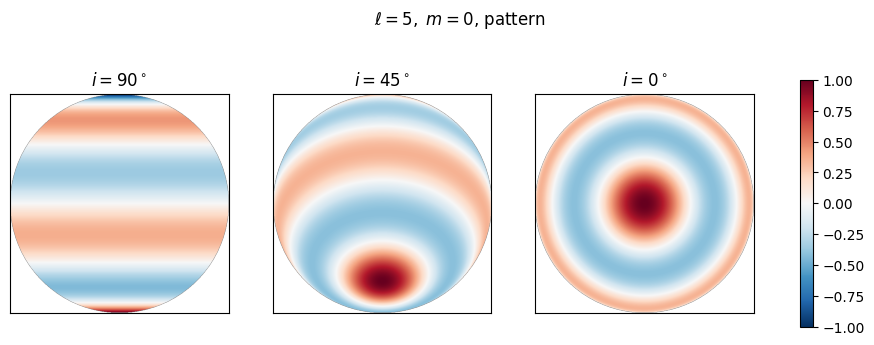

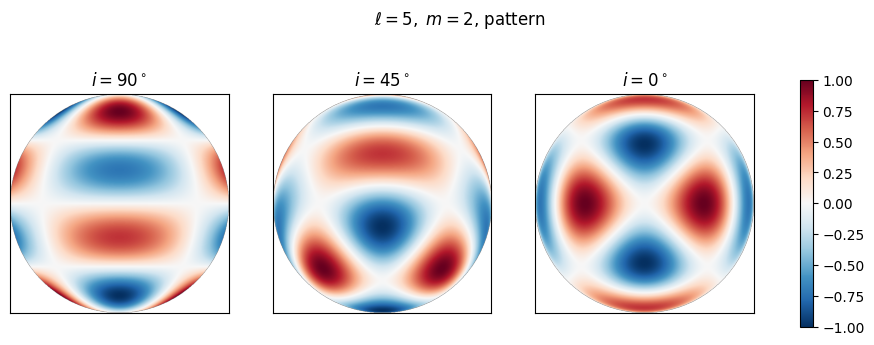

In [5]:
plot_mode_grid(ell=5, m=0, quantity="pattern")
plot_mode_grid(ell=5, m=2, quantity="pattern")

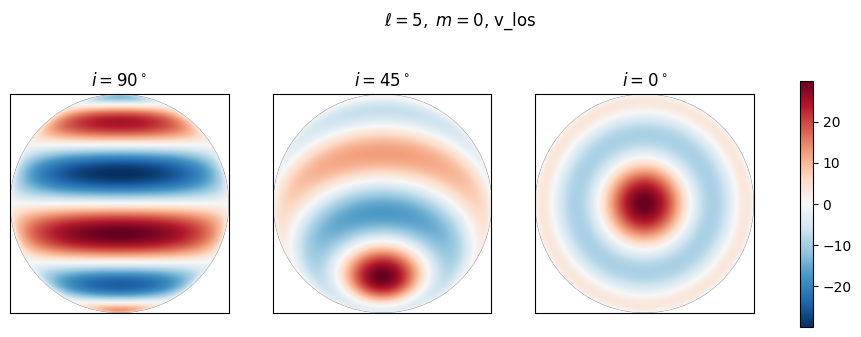

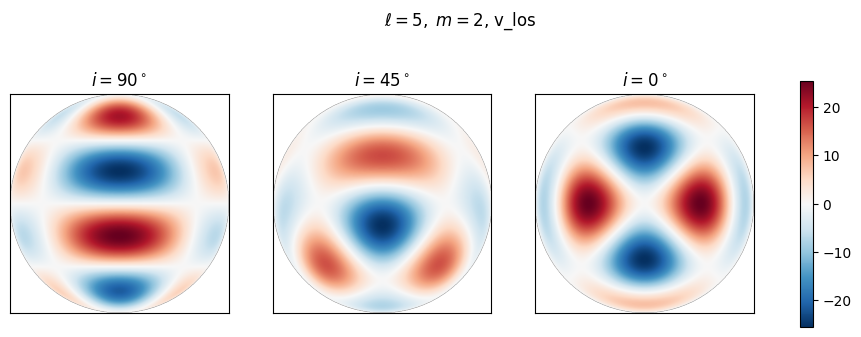

In [6]:
plot_mode_grid(ell=5, m=0, quantity="v_los")
plot_mode_grid(ell=5, m=2, quantity="v_los")

Looks like we get the expected geometry right.

Now we will try to fix the pheobe mesh. Let's do that for radial component first.


Let's first look at the phoebe mesh coordinates

#### Phoebe mesh coordinates

In [16]:
def compare_phoebe_coordinate_pairs(s_t):
    import matplotlib.pyplot as plt
    import numpy as np

    pairs = [
        ("us@primary", "vs@primary"),
        ("xs@primary", "ys@primary"),
        ("us@primary", "ws@primary"),
        ("vs@primary", "ws@primary"),
        ("xs@primary", "zs@primary"),
        ("ys@primary", "zs@primary"),
    ]

    vis = np.asarray(s_t["visibilities@primary"].get_value()) > 0

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()

    for ax, (kx, ky) in zip(axes, pairs):
        x = np.asarray(s_t[kx].get_value())
        y = np.asarray(s_t[ky].get_value())

        ax.scatter(x[vis], y[vis], s=3, alpha=0.7)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"{kx} vs {ky}")
        ax.set_xlabel(kx)
        ax.set_ylabel(ky)

    plt.tight_layout()
    plt.show()

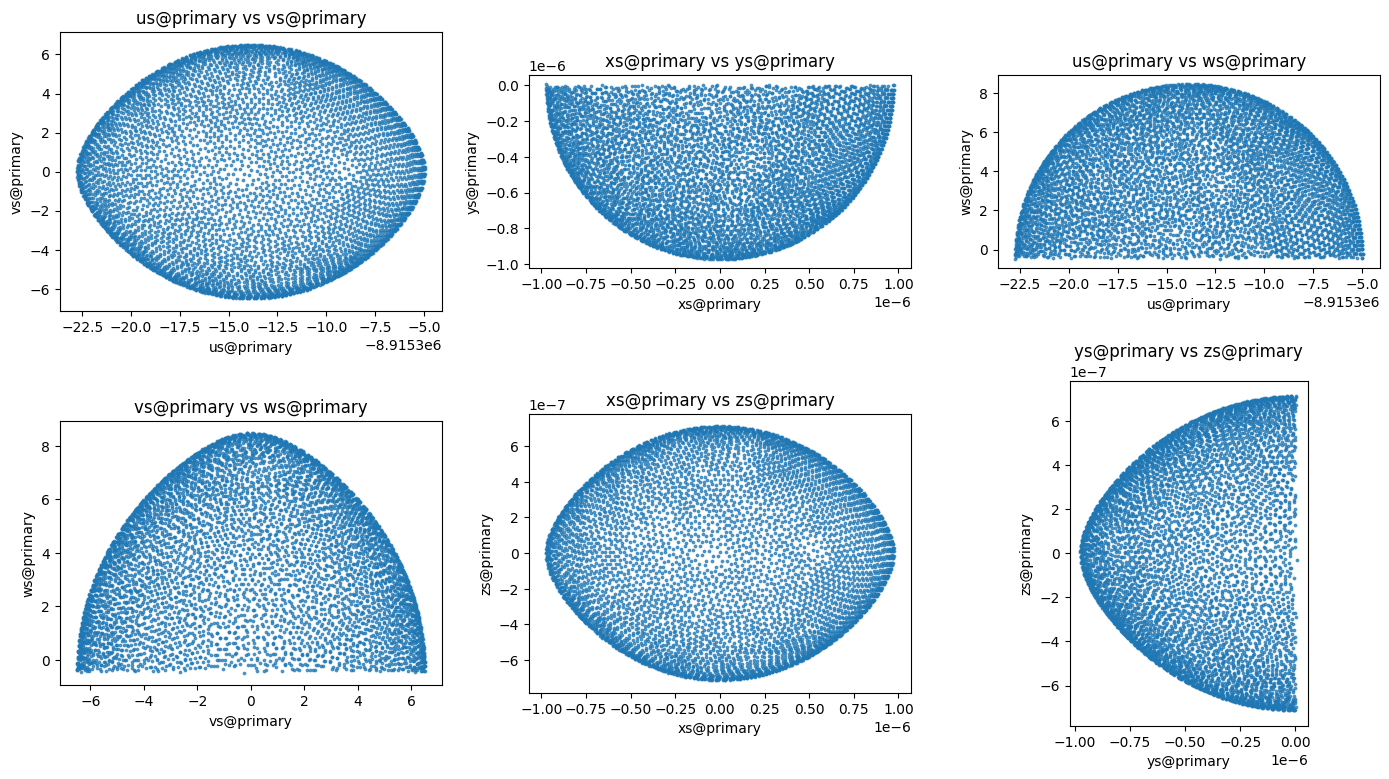

In [17]:
compare_phoebe_coordinate_pairs(s_t)

#### vlos on phoebe coordinates

In [7]:
def radial_los_velocity_on_observer_mesh(
    mesh,
    ell,
    m,
    inclination_deg,
    phase=0.0,
    amplitude=30.0,
):
    """
    Compute radial NRP line-of-sight velocity on a PHOEBE mesh.

    Plotting remains in observer frame:
        X_obs = mesh["x"]
        Y_obs = mesh["y"]

    Mode evaluation is done in stellar frame:
        Xs, Ys, Zs
    """

    X = mesh["x"]
    Y = mesh["y"]
    Z = mesh["z"]

    # Convert observer-frame coordinates into stellar-frame coordinates
    Xs, Ys, Zs = observer_to_stellar_frame(X, Y, Z, inclination_deg)

    r = np.sqrt(Xs**2 + Ys**2 + Zs**2)
    theta = np.arccos(np.clip(Zs / r, -1, 1))
    phi = np.mod(np.arctan2(Ys, Xs), 2*np.pi)

    m_abs = abs(m)

    lat = lpmv(m_abs, ell, np.cos(theta))

    if m >= 0:
        lon = np.cos(m_abs * phi + phase)
    else:
        lon = np.sin(m_abs * phi + phase)

    pattern = lat * lon
    pattern /= np.nanmax(np.abs(pattern))

    v_r = amplitude * pattern

    # radial LOS projection in observer frame
    # for a spherical surface, this is Z_obs / R_obs
    R_obs = np.sqrt(X**2 + Y**2 + Z**2)
    mu_geom = Z / R_obs

    # or, if PHOEBE mus is reliable:
    # mu_geom = mesh["mus"]

    v_los_r = v_r * mu_geom

    return {
        "pattern": pattern,
        "v_r": v_r,
        "v_los_r": v_los_r,
        "theta": theta,
        "phi": phi,
        "mu": mu_geom,
    }


def plot_phoebe_observer_nrp(
    mesh,
    ell=5,
    m=2,
    inclination_deg=90,
    phase=0.0,
    amplitude=30.0,
    quantity="v_los_r",
):
    out = radial_los_velocity_on_observer_mesh(
        mesh,
        ell=ell,
        m=m,
        inclination_deg=inclination_deg,
        phase=phase,
        amplitude=amplitude,
    )

    X = mesh["x"]
    Y = mesh["y"]
    vis = mesh["vis"] > 0

    values = out[quantity]

    vmax = np.nanmax(np.abs(values[vis]))

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(
        X[vis],
        Y[vis],
        c=values[vis],
        s=10,
        cmap="RdBu_r",
        edgecolor="none",
        vmin=-vmax,
        vmax=vmax,
    )

    plt.gca().set_aspect("equal")
    plt.xlabel(r"$X_{\rm obs}$")
    plt.ylabel(r"$Y_{\rm obs}$")
    plt.colorbar(sc, label=quantity)
    plt.title(
        rf"Observer frame: $\ell={ell}$, $m={m}$, "
        rf"$i={inclination_deg:.0f}^\circ$"
    )
    plt.tight_layout()
    plt.show()

    return out

In [8]:
def extract_observer_mesh_from_spamms_phoebe(s_t):
    """
    Use the original SPAMMS/PHOEBE coordinate convention:

    Xobs = us
    Yobs = vs
    Zlos = ws

    but recenter them so the stellar disk is properly centered.
    """

    from phoebe import u
    import numpy as np

    U = np.asarray(s_t["us@primary"].get_value(), dtype=float)
    V = np.asarray(s_t["vs@primary"].get_value(), dtype=float)
    W = np.asarray(s_t["ws@primary"].get_value(), dtype=float)

    mus = np.asarray(s_t["mus@primary"].get_value(), dtype=float)
    vis = np.asarray(s_t["visibilities@primary"].get_value(), dtype=float)
    rvs = np.asarray(
        s_t["rvs@primary@mesh"].get_value(unit=u.km/u.s),
        dtype=float
    )

    mesh = {
        "Xobs": U,
        "Yobs": V,
        "Zlos": W,

        # aliases used by plotting functions
        "x": U,
        "y": V,
        "z": W,

        "mus": mus,
        "vis": vis,
        "rvs": rvs,
    }

    return mesh

In [9]:
def center_mesh_coordinates(mesh):
    mesh = mesh.copy()
    vis = mesh["vis"] > 0
    for key in ["x", "y", "z", "Xobs", "Yobs", "Zlos"]:
        mesh[key] = np.asarray(mesh[key], dtype=float)

    # subtract mean of visible hemisphere only
    mesh["x"] = mesh["x"] - np.nanmean(mesh["x"][vis])
    mesh["y"] = mesh["y"] - np.nanmean(mesh["y"][vis])
    mesh["z"] = mesh["z"] - np.nanmean(mesh["z"][vis])

    mesh["Xobs"] = mesh["x"]
    mesh["Yobs"] = mesh["y"]
    mesh["Zlos"] = mesh["z"]

    return mesh

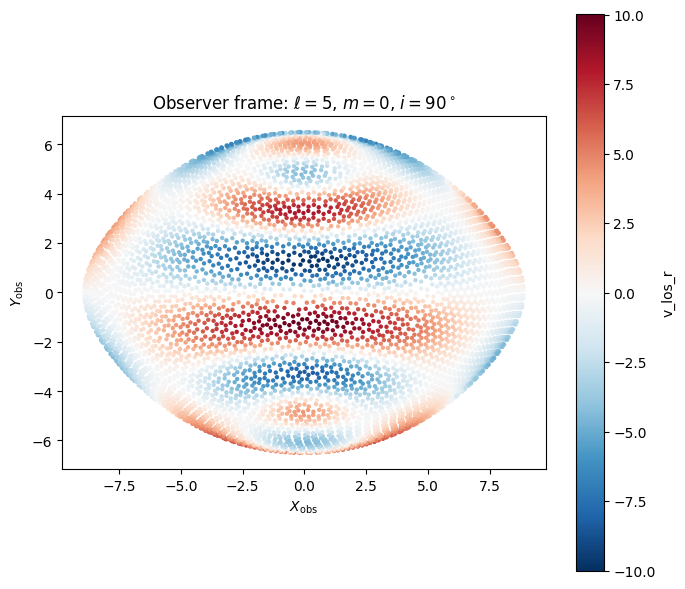

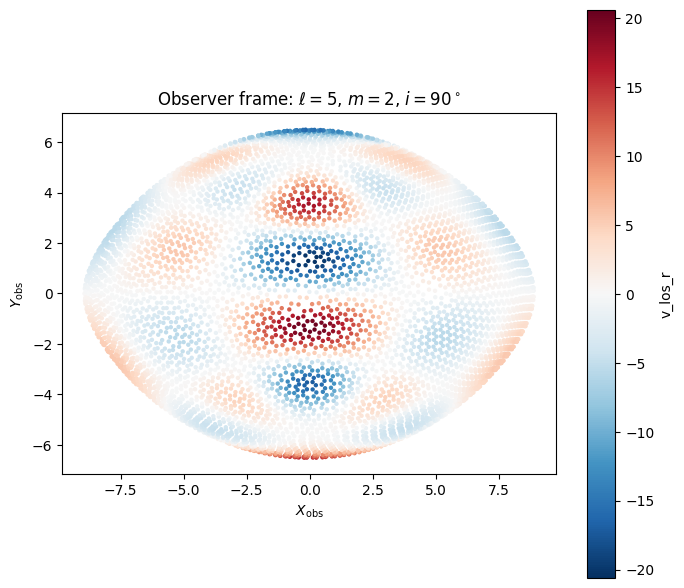

{'pattern': array([-0.03279018, -0.05948302, -0.02927259, ..., -0.32272009,
        -0.25487166, -0.293843  ]),
 'v_r': array([-0.98370542, -1.7844906 , -0.87817783, ..., -9.68160271,
        -7.64614978, -8.81529005]),
 'v_los_r': array([0.40302138, 0.76328949, 0.39073328, ..., 8.28131145, 6.47095818,
        7.51248868]),
 'theta': array([1.55715802, 1.54481641, 1.55740711, ..., 2.09450507, 2.11588159,
        2.10421254]),
 'phi': array([5.86102141, 5.84103982, 5.82203753, ..., 4.55572975, 4.56896004,
        4.56878081]),
 'mu': array([-0.40969723, -0.42773523, -0.44493639, ..., -0.85536576,
        -0.84630283, -0.85221117])}

In [13]:
mesh_obs = extract_observer_mesh_from_spamms_phoebe(s_t)
mesh_obs = center_mesh_coordinates(mesh_obs)

plot_phoebe_observer_nrp(
    mesh_obs,
    ell=5,
    m=0,
    inclination_deg=run_dictionary["inclination"],
    phase=0.0,
    amplitude=30.0,
    quantity="v_los_r",
)

plot_phoebe_observer_nrp(
    mesh_obs,
    ell=5,
    m=2,
    inclination_deg=run_dictionary["inclination"],
    phase=0.0,
    amplitude=30.0,
    quantity="v_los_r",
)